# Final Project 1: End-to-End Tabular Classification

            ## 1. Learning objectives

            - Audit a health benchmark
- Compare a constant baseline and three model families
- Tune, evaluate, and analyze classification errors

            ## 2. Prerequisites

            Complete the corresponding numbered course section and understand leakage-safe train/validation/test roles.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Predict the diagnostic class in the Breast Cancer Wisconsin benchmark. Primary success metric is F1; ROC-AUC and the confusion matrix are guardrails.

            ## 4. Real-world use cases

            - Educational diagnostic modeling
- Tabular pipeline comparison
- Error-cost discussion

            ## 5. Core intuition in simple language

            Start with a majority baseline, preserve the untouched test set, compare linear and tree-based candidates, then inspect false positives and negatives.

## 6. Mathematical foundation

            $$\widehat{Risk}_{test}=\frac{1}{n_{test}}\sum_{i=1}^{n_{test}}L(y_i,\hat y_i).$$

            **Every symbol:**

            - $n_{test}$ is held-out test size.
- $L$ is the chosen per-example loss.
- $y_i$ is truth.
- $\hat y_i$ is the frozen model prediction.
- $\widehat{Risk}_{test}$ is estimated generalization error.

            **Why the equation is needed:** The held-out average connects the technical model to a predeclared success criterion.

            **Small numerical example:** If 3 of 100 equally weighted test cases are wrong, error is 3/100=.03 and accuracy is .97.

            **Connection to Python:** metric(y_test, model.predict(X_test)) evaluates the frozen pipeline once.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Define decision and success metric
2. Describe and audit data
3. Split before fitted preprocessing
4. Create a simple baseline
5. Compare candidate models
6. Tune on development data
7. Evaluate once on test data
8. Analyze errors and limitations

## 9. Implementation from scratch

A transparent baseline verifies label and metric semantics before complex modeling.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def majority_prediction(target,size):
    labels,counts=np.unique(target,return_counts=True)
    return np.full(size,labels[np.argmax(counts)])

example=np.array([0,1,1,1,0])
print("Majority predictions:",majority_prediction(example,3))

Majority predictions: [1 1 1]


## 10. Implementation using a standard library

Standard libraries provide reproducible pipelines and robust implementations; decisions remain visible in code.

## 11. Dataset loading and exploration

The project uses a small bundled dataset so every result can be reproduced offline.

## 12. Data preprocessing

Cleaning and feature transformations are fitted only on development or training rows.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Rows/features: (569, 30) missing: 0 duplicates: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


,model,F1,ROC-AUC
1,Logistic,0.993,0.998
3,Gradient boosting,0.972,0.993
2,Random forest,0.958,0.983
0,Majority baseline,0.768,0.500


Selected: Logistic test F1: 0.986 test ROC-AUC: 0.995


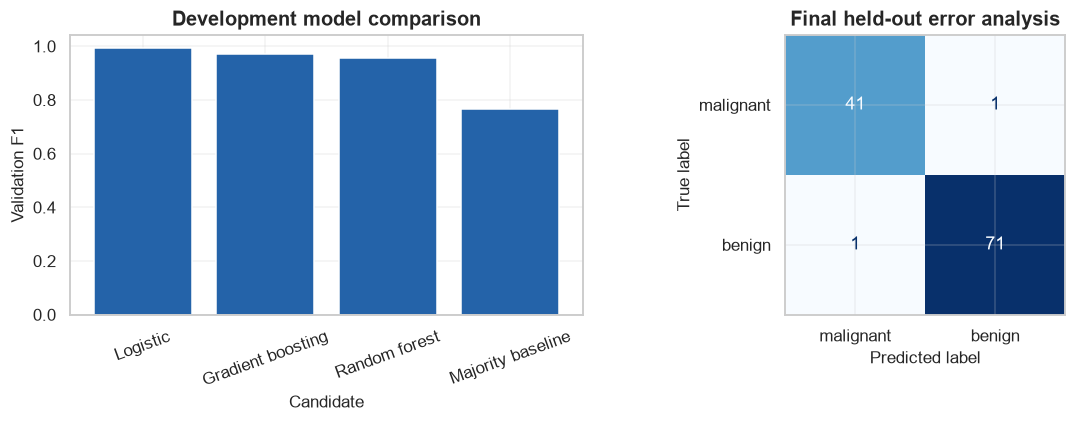

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay,f1_score,roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

data=load_breast_cancer(as_frame=True)
frame=data.frame.copy()
print("Rows/features:",data.data.shape,"missing:",int(frame.isna().sum().sum()),"duplicates:",int(frame.duplicated().sum()))
display(frame.head(3))
X_development,X_test,y_development,y_test=train_test_split(data.data,data.target,test_size=.2,stratify=data.target,random_state=RANDOM_SEED)
X_train,X_validation,y_train,y_validation=train_test_split(X_development,y_development,test_size=.25,stratify=y_development,random_state=RANDOM_SEED)
baseline=majority_prediction(y_train,len(y_validation))
candidates={
    "Logistic":make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000,random_state=RANDOM_SEED)),
    "Random forest":RandomForestClassifier(n_estimators=160,max_depth=5,random_state=RANDOM_SEED),
    "Gradient boosting":GradientBoostingClassifier(random_state=RANDOM_SEED),
}
rows=[{"model":"Majority baseline","F1":f1_score(y_validation,baseline),"ROC-AUC":.5}]
for name,model in candidates.items():
    model.fit(X_train,y_train); prediction=model.predict(X_validation); probability=model.predict_proba(X_validation)[:,1]
    rows.append({"model":name,"F1":f1_score(y_validation,prediction),"ROC-AUC":roc_auc_score(y_validation,probability)})
comparison=pd.DataFrame(rows).sort_values("F1",ascending=False)
display(comparison.round(3))
best_name=comparison.iloc[0]["model"]; best_model=candidates[best_name]
best_model.fit(X_development,y_development)
test_prediction=best_model.predict(X_test); test_probability=best_model.predict_proba(X_test)[:,1]
print("Selected:",best_name,"test F1:",round(f1_score(y_test,test_prediction),3),"test ROC-AUC:",round(roc_auc_score(y_test,test_probability),3))
figure,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].bar(comparison["model"],comparison["F1"],color=COURSE_COLORS["blue"]); axes[0].set(title="Development model comparison",xlabel="Candidate",ylabel="Validation F1"); axes[0].tick_params(axis="x",rotation=20)
ConfusionMatrixDisplay.from_predictions(y_test,test_prediction,display_labels=data.target_names,cmap="Blues",colorbar=False,ax=axes[1]); axes[1].set_title("Final held-out error analysis")
figure.tight_layout(); plt.show()

**How to interpret the result:** The comparison establishes whether complexity improves on the baseline; the confusion matrix exposes the exact final error types.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Tree depth is varied using validation F1. The test set is not consulted during this experiment.

,max_depth,validation_F1
0,2,0.958
1,3,0.958
2,5,0.958
3,8,0.965
4,None,0.965


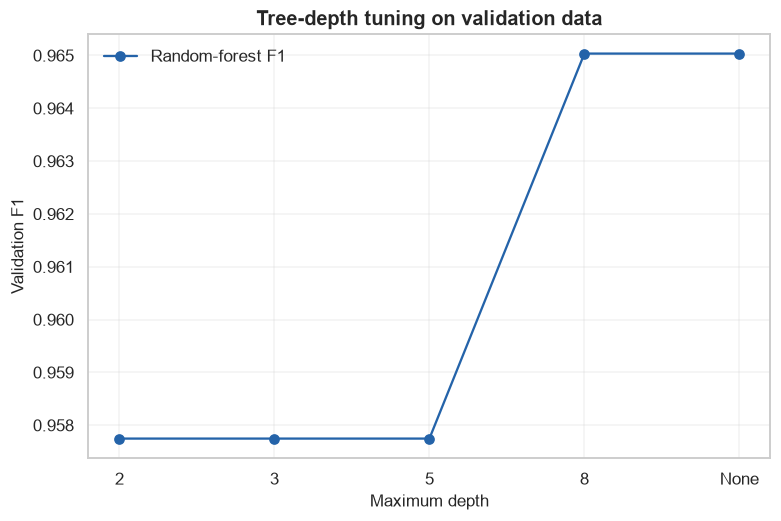

In [4]:
depth_rows=[]
for depth in [2,3,5,8,None]:
    model=RandomForestClassifier(n_estimators=160,max_depth=depth,random_state=RANDOM_SEED).fit(X_train,y_train)
    depth_rows.append({"max_depth":str(depth),"validation_F1":f1_score(y_validation,model.predict(X_validation))})
depth_results=pd.DataFrame(depth_rows)
display(depth_results.round(3))
figure,axis=plt.subplots(); axis.plot(depth_results["max_depth"],depth_results["validation_F1"],marker="o",color=COURSE_COLORS["blue"],label="Random-forest F1")
axis.set(title="Tree-depth tuning on validation data",xlabel="Maximum depth",ylabel="Validation F1"); axis.legend(); plt.show()

## 18. Common mistakes

            - Starting with a model before defining success
- Fitting preprocessing before splitting
- Selecting on test performance
- Hiding failure modes behind one aggregate score

            ## 19. Advantages and disadvantages

            **Advantages**

            - Reproducible end-to-end evidence
- Explicit comparison and limitations

            **Disadvantages**

            - Benchmark data does not prove deployment readiness
- Offline metrics omit operational costs

            ## 20. When to use and when not to use the algorithm

            **Use it when:** the dataset, metric, and decision are aligned and the result will be treated as evidence rather than certainty.

            **Do not use it when:** used as a clinical system without prospective validation, calibration, subgroup audits, and medical governance.

## 21. Exercises

1. **Conceptual:** Which decision does the model support?
2. **Mathematical/hand calculation:** Recalculate the primary metric on a tiny example by hand.
3. **Coding/experimentation:** Repeat the final comparison over multiple seeds or splits.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. State the user, action, model output, and consequence in one sentence.
2. Apply the displayed metric to each example, sum, and divide by the correct denominator.
3. Keep preprocessing and candidate definitions fixed, report every run, and summarize mean plus variability.

</details>

## Capstone delivery checklist

- **Business or real-world problem and success metric:** defined before modeling in the problem-definition section.
- **Dataset description and exploratory data analysis:** documented beside the bounded dataset preview and audit outputs.
- **Data cleaning and feature engineering:** performed after the split where fitting or target information could otherwise leak; choices are stated explicitly, including when no cleaning is required.
- **Baseline and multiple-model comparison:** a simple reference model is evaluated before more flexible candidates.
- **Hyperparameter tuning:** candidates are selected only with development or validation evidence.
- **Final evaluation and error analysis:** the frozen choice is assessed on untouched data with a task-appropriate diagnostic plot.
- **Limitations and possible improvements:** recorded with the disadvantages and interpretation so the result is not overstated.
- **Final conclusion:** the summary connects the evidence, limitations, and next steps.

## 23. Summary and key takeaways

            - The workflow is part of the model
- Baselines and data leakage checks precede tuning
- Final evaluation uses untouched data
- Error analysis, limitations, and possible improvements belong in the conclusion

            ## 24. Further reading

            - [scikit-learn model selection](https://scikit-learn.org/stable/model_selection.html)
- [PyTorch tutorials](https://pytorch.org/tutorials/)